# Saudi Football Infrastructure — Full Analysis

Comprehensive notebook for the Saudi Football Study. Pulls live data from Supabase and runs every analysis used in the deck plus deeper cuts.

**Data source:** Supabase project `Football_Fields_Mapping&Demographic_analysis_SA`
**REST base:** `https://hdcqusmfyovcvtdlawbm.supabase.co/rest/v1/`
**Auth:** publishable (anon) key — read-only

## Sections
1. Setup & data load
2. Data quality scorecard
3. Facility type breakdown (Q2)
4. Regional supply density (Q1 & Q4)
5. Interactive facilities map (folium)
6. Pitch deserts (Q3)
7. SAFF accreditation gap (Q5/Q6)
8. Women's facilities and PA (Q7/Q8)
9. Correlation matrix and Q9 hypothesis tests
10. Q10 investment tier priorities
11. Country benchmark
12. K-means regional clustering
13. Pitch supply gap to UEFA target
14. Google rating distribution
15. Academy density vs proxy player count
16. Vision 2030 target tracking
17. Export charts & CSVs

> **Tip:** run cells top-to-bottom on first pass. Each section is self-contained after data load.


## 1. Setup

Install non-default packages, then import everything.

In [18]:
# Run once per Colab session
!pip install -q folium scikit-learn statsmodels seaborn requests pandas matplotlib numpy scipy


In [19]:
import os
import json
import math
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import folium
from folium.plugins import MarkerCluster, HeatMap
import warnings
warnings.filterwarnings('ignore')

# Output directory for exports
OUTDIR = '/content/outputs'
os.makedirs(OUTDIR, exist_ok=True)

print('Imports OK. Output dir:', OUTDIR)


Imports OK. Output dir: /content/outputs


### Visual style

Centralized palette so every chart is consistent. Saudi greens for positive, red for negative, navy for benchmark / reference.

In [20]:
# Palette - matches the deck
GREEN_DARK  = "#3D8757"
GREEN_MID   = "#6CB682"
GREEN_LIGHT = "#BFDFCB"
GREEN_PALE  = "#E5F2EA"
TEXT_DARK   = "#1F1F1F"
GRAY_MUTED  = "#6B6B6B"
RED_ACCENT  = "#C75050"
ORANGE_ACCENT = "#E89B3B"
NAVY_ACCENT = "#1E3A5F"
PURPLE_ACCENT = "#9C66B3"
BLUE_ACCENT = "#3B92C9"

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#888888',
    'axes.labelcolor': TEXT_DARK,
    'xtick.color': TEXT_DARK,
    'ytick.color': TEXT_DARK,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})
sns.set_palette([GREEN_DARK, RED_ACCENT, NAVY_ACCENT, ORANGE_ACCENT, PURPLE_ACCENT, BLUE_ACCENT])


## 2. Data load

Pull every table and view from Supabase via REST. Stored as `df_*` DataFrames.

**Note:** the publishable key below is read-only and safe to commit. If it ever leaks, rotate it from the Supabase dashboard.

In [21]:
SUPABASE_URL = "https://hdcqusmfyovcvtdlawbm.supabase.co"
PUBLISHABLE_KEY = "sb_publishable_uhXX_xRAVZ2s6nKtJiWCmw_8UPPQQTu"

HEADERS = {
    "apikey": PUBLISHABLE_KEY,
    "Authorization": f"Bearer {PUBLISHABLE_KEY}",
    "Accept": "application/json",
    "Prefer": "count=exact",
}

def fetch_table(name, select="*", limit=10000):
    """Fetch a Supabase table/view via REST. Returns DataFrame."""
    url = f"{SUPABASE_URL}/rest/v1/{name}"
    params = {"select": select, "limit": str(limit)}
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    return pd.DataFrame(r.json())

# Load everything
df_master       = fetch_table("v_regional_master")
df_facilities   = fetch_table("v_facilities_map")
df_priorities   = fetch_table("v_q10_priorities")
df_quality      = fetch_table("v_data_quality")
df_q3           = fetch_table("q3_pitch_deserts")
df_q9           = fetch_table("q9_correlations")
df_q2_pop       = fetch_table("q2_population_estimates")
df_q2_sample    = fetch_table("q2_sample_coding")
df_demographics = fetch_table("regional_demographics")
df_pa           = fetch_table("regional_pa_2025")
df_women        = fetch_table("regional_women_facilities")
df_saff         = fetch_table("saff_accredited")

print(f"Loaded {len(df_master)} regions")
print(f"Loaded {len(df_facilities)} facility points")
print(f"Loaded {len(df_q3)} pitch-desert rows")
print(f"Loaded {len(df_q9)} correlation tests")
print(f"Loaded {len(df_priorities)} priority tiers")
df_master.head()


Loaded 13 regions
Loaded 1000 facility points
Loaded 15 pitch-desert rows
Loaded 7 correlation tests
Loaded 13 priority tiers


,region_id,region_name_en,region_name_ar,population,youth_5_24,pa_total_pct,pa_women_pct,pa_men_pct,gender_gap_pp,total_facilities,...,stadiums,mean_google_rating,pitches_per_10k,facilities_per_10k,academies_per_10k_youth,women_halls,women_halls_per_100k,saff_accredited,saff_accreditation_rate_pct,estimated_inactive_women_18plus
0,riyadh_region,Riyadh,الرياض,9426231,2728550,59.01,45.83,67.06,21.3,307,...,21,4.25,0.232,0.326,0.128,502,5.33,2,2.7,1393377
1,makkah_region,Makkah,مكة المكرمة,8524663,2601509,67.61,48.66,79.13,30.4,286,...,24,4.31,0.233,0.335,0.181,265,3.11,2,2.4,1194276
2,eastern_region,Eastern Region,المنطقة الشرقية,5623050,1625578,49.68,37.25,57.27,19.9,418,...,26,4.26,0.562,0.743,0.289,187,3.33,3,3.4,962847
3,jizan_region,Jizan,جازان,1541458,536713,57.81,42.18,67.35,25.1,135,...,4,4.21,0.655,0.876,0.224,55,3.57,2,6.5,243210
4,qassim_region,Qassim,القصيم,1465956,482741,54.80,40.83,63.32,22.5,157,...,4,4.24,0.784,1.071,0.394,40,2.73,2,5.3,236698


## 3. Data quality scorecard

Per-source completeness, recency, confidence. This drives how much weight each finding deserves.

,source_table,records,source,recency,pct_complete,confidence,notes
0,facilities,1997,Google Places API,2026-04,96.3,High,Coverage strong; phone/website blank (collecto...
1,regional_demographics,13,GASTAT Census 2022 + 2024 estimates (citypopul...,2024,100.0,High,Calibrated to GASTAT national totals
2,regional_pa_2025,13,GASTAT Physical Activity 2025 + 2021 Sports Pr...,2025,100.0,Medium-High,Women PA per region is hybrid estimate (2025 t...
3,saff_accredited,69,SAFF Accredited Clubs & Academies PDF (Oct 2023),2023-10,100.0,Medium,OCR from PDF zip; only 32% match facilities ta...
4,regional_women_facilities,13,MOS Open Data (الصالات والمراكز الرياضية),2024,100.0,High,"MOS reports 1,175 women halls nationally"
5,q2_sample_coding,106,Hand-coded by Claude from facility names,2026-05,80.2,Medium,"19.8% raw ""unclear"" allocated proportionally; ..."
6,q3_pitch_deserts,15,Geospatial computation on facilities lat/lng,2026-05,100.0,Medium-High,Convex hull approach with 1km buffer; Euclidea...
7,q9_correlations,7,Computed from regional_master,2026-05,100.0,Medium,"Coarse n=13; trends valid, point estimates wid..."


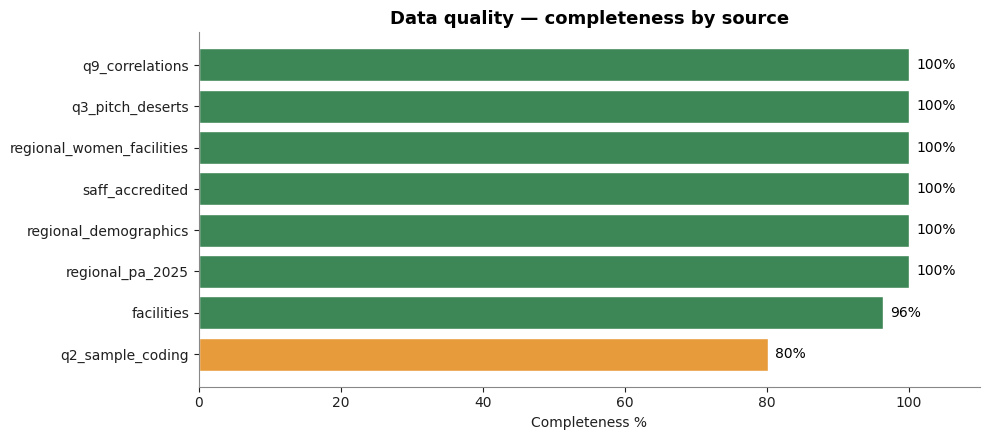

In [22]:
# Pretty print the data quality table
df_quality_display = df_quality.copy()
df_quality_display['pct_complete'] = df_quality_display['pct_complete'].astype(float).round(1)
display(df_quality_display)

# Completeness bar chart
fig, ax = plt.subplots(figsize=(10, 4.5))
df_q = df_quality.sort_values('pct_complete')
colors = [GREEN_DARK if p >= 95 else (ORANGE_ACCENT if p >= 80 else RED_ACCENT) for p in df_q['pct_complete']]
bars = ax.barh(df_q['source_table'], df_q['pct_complete'].astype(float), color=colors, edgecolor='white')
for bar, v in zip(bars, df_q['pct_complete']):
    ax.text(float(v) + 1, bar.get_y() + bar.get_height()/2, f'{float(v):.0f}%',
            va='center', fontsize=10)
ax.set_xlabel('Completeness %')
ax.set_xlim(0, 110)
ax.set_title('Data quality — completeness by source')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/01_data_quality.png')
plt.show()


## 4. Facility type breakdown (Q2)

What's actually out there? Facility counts by type, plus the public/commercial/mixed split.

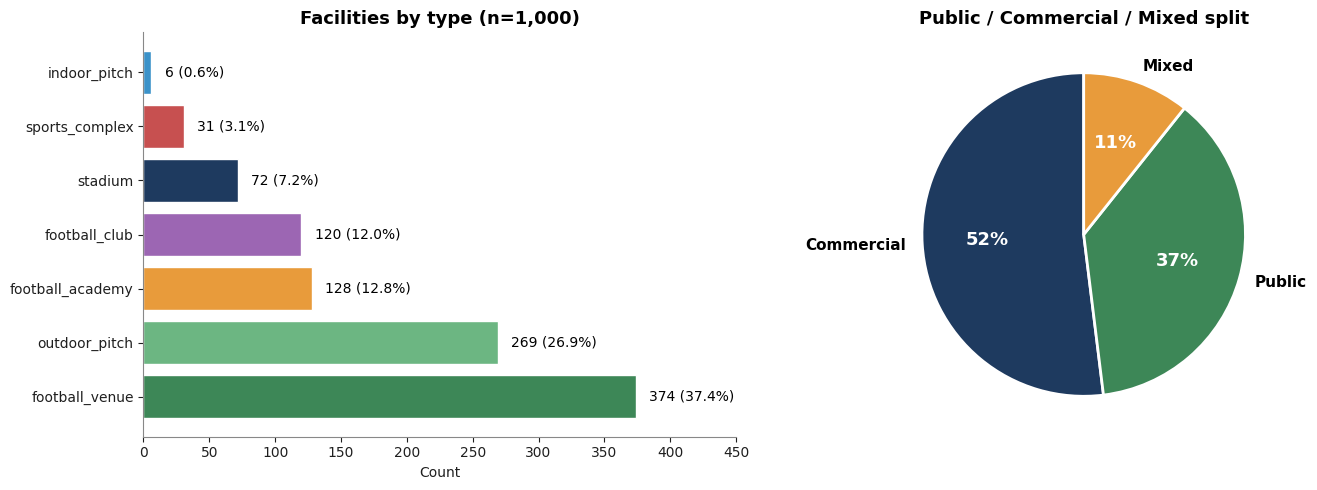

Total facilities: 1,000
Public:     37.3% (CI 31.7-42.9%)
Commercial: 51.9%
Mixed:      10.7%


In [23]:
# Count by facility type
type_counts = df_facilities['facility_type'].value_counts()
total = type_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) bar chart of types
ax = axes[0]
colors_map = {
    'football_venue': GREEN_DARK,
    'outdoor_pitch': GREEN_MID,
    'football_club': PURPLE_ACCENT,
    'football_academy': ORANGE_ACCENT,
    'stadium': NAVY_ACCENT,
    'sports_complex': RED_ACCENT,
    'indoor_pitch': BLUE_ACCENT,
}
colors = [colors_map.get(t, GRAY_MUTED) for t in type_counts.index]
bars = ax.barh(type_counts.index, type_counts.values, color=colors, edgecolor='white')
for bar, v in zip(bars, type_counts.values):
    pct = v / total * 100
    ax.text(v + total*0.01, bar.get_y() + bar.get_height()/2,
            f'{v:,} ({pct:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('Count')
ax.set_title(f'Facilities by type (n={total:,})')
ax.set_xlim(0, total * 0.45)

# (b) pie of public/commercial/mixed
ax = axes[1]
pop = df_q2_pop[df_q2_pop['category'].isin(['public','commercial','mixed'])].sort_values('share_point_pct', ascending=False)
wedges, texts, autotexts = ax.pie(
    pop['share_point_pct'], labels=pop['category'].str.title(),
    autopct='%1.0f%%',
    colors=[NAVY_ACCENT, GREEN_DARK, ORANGE_ACCENT],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11, fontweight='bold'),
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
ax.set_title('Public / Commercial / Mixed split')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/02_facility_types.png')
plt.show()

print(f"Total facilities: {total:,}")
print(f"Public:     {pop[pop['category']=='public']['share_point_pct'].iloc[0]}% (CI {pop[pop['category']=='public']['share_low_pct'].iloc[0]}-{pop[pop['category']=='public']['share_high_pct'].iloc[0]}%)")
print(f"Commercial: {pop[pop['category']=='commercial']['share_point_pct'].iloc[0]}%")
print(f"Mixed:      {pop[pop['category']=='mixed']['share_point_pct'].iloc[0]}%")


## 5. Regional supply density (Q1 & Q4)

Pitches per 10k population and academies per 10k youth, by region.

**UEFA "well-served" benchmark:** 1.0 pitches per 10k.

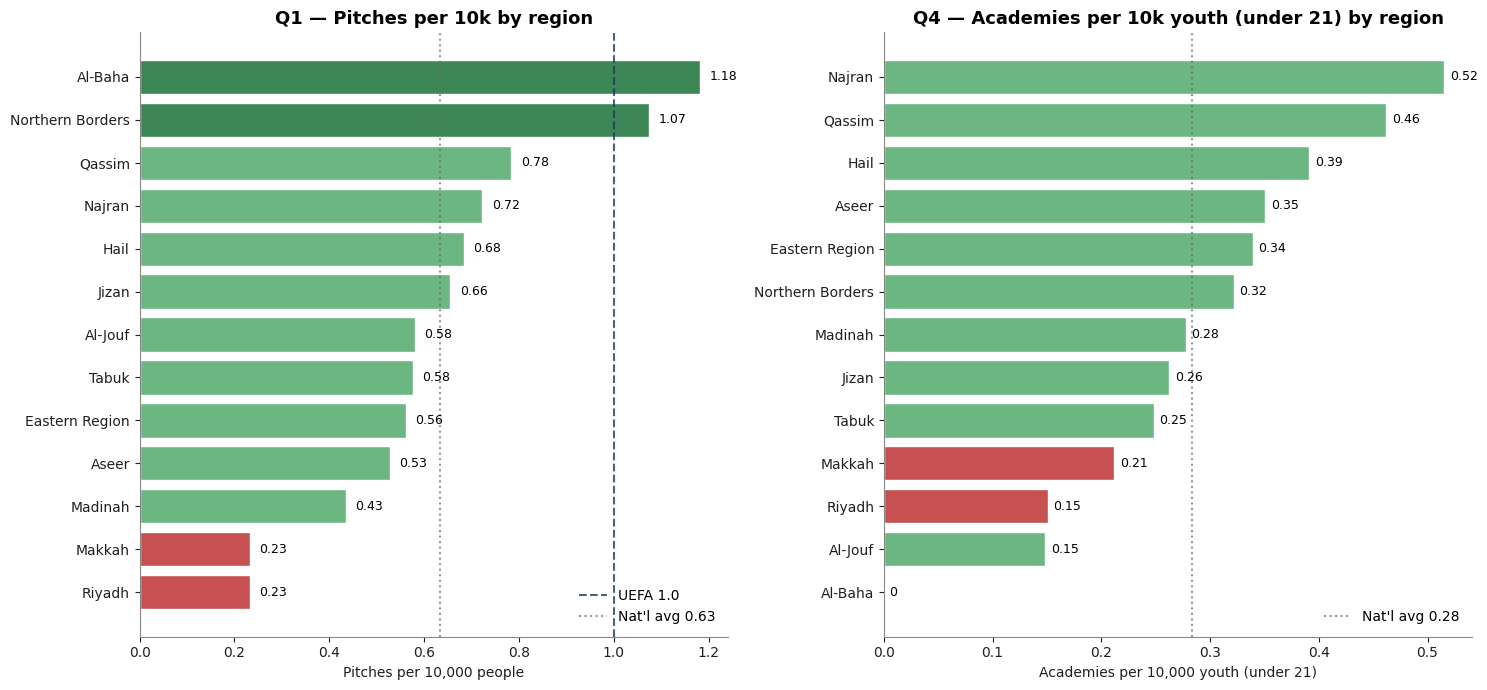


National averages: 0.63 pitches/10k · 0.28 academies/10k youth (under 21)
5x range: Al-Baha 1.18 → Riyadh/Makkah 0.23
Youth (under 21) total: 9,205,293


In [24]:
# ============================================================
# Cell — Q1 (pitches/10k) + Q4 (academies/10k youth UNDER 21)
# Drop-in replacement. Youth definition is now "under 21"
# (was 5–24). Calibrated to GASTAT 2024 ≈ 9.2M.
# ============================================================

UEFA_BENCHMARK = 1.0

# ─── Recompute academies_per_10k_youth using under-21 denominator ──
NATIONAL_5_24    = 10_800_000   # previous denominator (5–24)
NATIONAL_UNDER21 =  9_200_000   # new denominator (0–20), GASTAT 2024

# Recover absolute academy count from the existing 5–24 metric so we
# can re-divide by the new under-21 denominator. (df_master has
# academies_per_10k_youth and youth_5_24, not n_academies directly.)
df_master['n_academies'] = (
    df_master['academies_per_10k_youth'].astype(float)
    * df_master['youth_5_24'].astype(float) / 10_000
).round().astype(int)

# Build under-21 youth column
if all(c in df_master.columns for c in ['pop_0_4','pop_5_9','pop_10_14','pop_15_19','pop_20_24']):
    df_master['youth_under21'] = (
        df_master['pop_0_4'] + df_master['pop_5_9']
        + df_master['pop_10_14'] + df_master['pop_15_19']
        + df_master['pop_20_24'] * (1/5)
    )
    scale = NATIONAL_UNDER21 / df_master['youth_under21'].sum()
    df_master['youth_under21'] *= scale
else:
    # Fallback: rescale existing youth_5_24 by national ratio
    df_master['youth_under21'] = df_master['youth_5_24'].astype(float) * (NATIONAL_UNDER21 / NATIONAL_5_24)

# Recompute density using under-21 denominator
df_master['academies_per_10k_youth'] = (
    df_master['n_academies'].astype(float) / df_master['youth_under21'].astype(float) * 10_000
)

NATIONAL_PITCH_AVG   = float(df_master['pitches_per_10k'].astype(float).mean())
NATIONAL_ACADEMY_AVG = float(df_master['academies_per_10k_youth'].astype(float).mean())

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ─── Q1: pitches per 10k ────────────────────────────────────────────
df_q1 = df_master.sort_values('pitches_per_10k', ascending=True)
ax = axes[0]
colors = []
for _, row in df_q1.iterrows():
    name = row['region_name_en']
    v = float(row['pitches_per_10k'])
    if name in ('Riyadh','Makkah'): colors.append(RED_ACCENT)
    elif v >= UEFA_BENCHMARK: colors.append(GREEN_DARK)
    else: colors.append(GREEN_MID)
ax.barh(df_q1['region_name_en'], df_q1['pitches_per_10k'].astype(float),
        color=colors, edgecolor='white')
ax.axvline(UEFA_BENCHMARK, color=NAVY_ACCENT, ls='--', alpha=0.8, label=f'UEFA {UEFA_BENCHMARK}')
ax.axvline(NATIONAL_PITCH_AVG, color=GRAY_MUTED, ls=':', alpha=0.7, label=f'Nat\'l avg {NATIONAL_PITCH_AVG:.2f}')
for i, v in enumerate(df_q1['pitches_per_10k'].astype(float)):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlabel('Pitches per 10,000 people')
ax.set_title('Q1 — Pitches per 10k by region')
ax.legend(loc='lower right', frameon=False)

# ─── Q4: academies per 10k youth (under 21) ────────────────────────
df_q4 = df_master.sort_values('academies_per_10k_youth', ascending=True)
ax = axes[1]
colors = []
for _, row in df_q4.iterrows():
    name = row['region_name_en']
    v = float(row['academies_per_10k_youth'])
    if name in ('Riyadh','Makkah'): colors.append(RED_ACCENT)
    elif v == 0: colors.append(RED_ACCENT)
    else: colors.append(GREEN_MID)
ax.barh(df_q4['region_name_en'], df_q4['academies_per_10k_youth'].astype(float),
        color=colors, edgecolor='white')
ax.axvline(NATIONAL_ACADEMY_AVG, color=GRAY_MUTED, ls=':', alpha=0.7, label=f'Nat\'l avg {NATIONAL_ACADEMY_AVG:.2f}')
for i, v in enumerate(df_q4['academies_per_10k_youth'].astype(float)):
    label = f'{v:.2f}' if v > 0 else '0'
    ax.text(v + 0.005, i, label, va='center', fontsize=9)
ax.set_xlabel('Academies per 10,000 youth (under 21)')
ax.set_title('Q4 — Academies per 10k youth (under 21) by region')
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig(f'{OUTDIR}/03_regional_density.png')
plt.show()

print(f"\nNational averages: {NATIONAL_PITCH_AVG:.2f} pitches/10k · {NATIONAL_ACADEMY_AVG:.2f} academies/10k youth (under 21)")
print(f"5x range: Al-Baha {df_master['pitches_per_10k'].astype(float).max():.2f} → Riyadh/Makkah {df_master['pitches_per_10k'].astype(float).min():.2f}")
print(f"Youth (under 21) total: {df_master['youth_under21'].sum():,.0f}")

## 6. Interactive facilities map

Pan, zoom, click a marker for details. Layer toggle for SAFF accredited subset. The map renders inline in Colab.

In [25]:
# Build interactive folium map
type_color = {
    'football_venue':     GREEN_DARK,
    'outdoor_pitch':      GREEN_MID,
    'football_club':      PURPLE_ACCENT,
    'football_academy':   ORANGE_ACCENT,
    'stadium':            NAVY_ACCENT,
    'sports_complex':     RED_ACCENT,
    'indoor_pitch':       BLUE_ACCENT,
}

m = folium.Map(location=[24.0, 45.0], zoom_start=6, tiles='cartodbpositron')

# Layer per facility type, all collapsible
df_clean = df_facilities.dropna(subset=['latitude','longitude']).copy()

for ftype, color in type_color.items():
    sub = df_clean[df_clean['facility_type'] == ftype]
    if sub.empty: continue
    fg = folium.FeatureGroup(name=f"{ftype.replace('_',' ').title()} ({len(sub):,})", show=True)
    cluster = MarkerCluster().add_to(fg)
    for _, row in sub.iterrows():
        popup_html = f'''<b>{row.get("name_en") or row.get("name_ar") or "Unnamed"}</b><br>
        Type: {ftype}<br>
        Region: {row.get("region_name_en","")}<br>
        Rating: {row.get("google_rating","-")} ({row.get("google_reviews_count",0)} reviews)<br>
        SAFF: {"Yes" if row.get("is_saff_accredited") else "No"}'''
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=4, color=color, fill=True, fillColor=color, fillOpacity=0.7,
            popup=folium.Popup(popup_html, max_width=300),
        ).add_to(cluster)
    fg.add_to(m)

# SAFF-only overlay
saff_layer = folium.FeatureGroup(name=f'★ SAFF Accredited ({df_clean["is_saff_accredited"].sum()})', show=False)
for _, row in df_clean[df_clean['is_saff_accredited']==True].iterrows():
    folium.Marker(
        [row['latitude'], row['longitude']],
        icon=folium.Icon(color='green', icon='star', prefix='fa'),
        popup=row.get('name_en') or row.get('name_ar') or 'SAFF accredited',
    ).add_to(saff_layer)
saff_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save(f'{OUTDIR}/04_interactive_map.html')
print(f"Saved interactive map to {OUTDIR}/04_interactive_map.html")
m


Saved interactive map to /content/outputs/04_interactive_map.html


### Heatmap variant — supply density

In [26]:
# Density heatmap (no markers, just heat)
m2 = folium.Map(location=[24.0, 45.0], zoom_start=6, tiles='cartodbpositron')
heat_data = df_clean[['latitude','longitude']].values.tolist()
HeatMap(heat_data, radius=12, blur=18, max_zoom=10).add_to(m2)
m2.save(f'{OUTDIR}/04b_density_heatmap.html')
m2


## 7. Pitch deserts (Q3)

Percentage of urban area more than X km from any pitch. The 2 km threshold matters most because it's roughly walking distance.

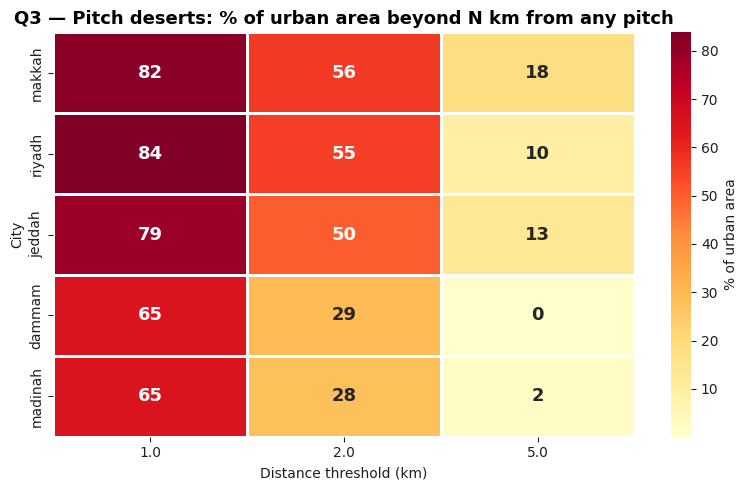

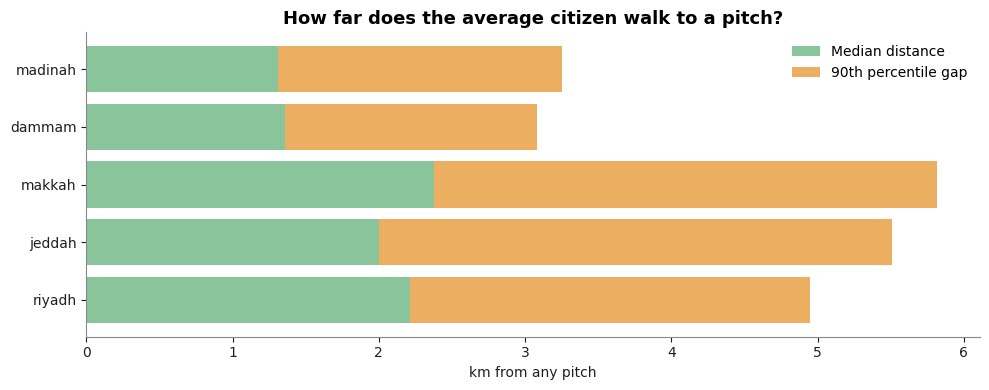

In [27]:
# Pivot Q3 to city × threshold heatmap
pivot = df_q3.pivot_table(index='city_id', columns='threshold_km', values='pct_desert')
pivot = pivot.sort_values(2.0, ascending=False)  # sort by 2km desert %

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': '% of urban area'}, linewidths=1, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'}, ax=ax)
ax.set_title('Q3 — Pitch deserts: % of urban area beyond N km from any pitch')
ax.set_xlabel('Distance threshold (km)')
ax.set_ylabel('City')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/05_pitch_deserts.png')
plt.show()

# Median + max distance per city
fig, ax = plt.subplots(figsize=(10, 4))
cities = df_q3.drop_duplicates('city_id')
ax.barh(cities['city_id'], cities['median_dist_km'].astype(float),
        color=GREEN_MID, label='Median distance', alpha=0.8)
ax.barh(cities['city_id'], cities['p90_dist_km'].astype(float) - cities['median_dist_km'].astype(float),
        left=cities['median_dist_km'].astype(float),
        color=ORANGE_ACCENT, label='90th percentile gap', alpha=0.8)
ax.set_xlabel('km from any pitch')
ax.set_title('How far does the average citizen walk to a pitch?')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/05b_distance_distribution.png')
plt.show()


## 8. SAFF accreditation gap (Q5/Q6)

Of the 473 clubs and academies in the database, only 22 are SAFF-accredited as of October 2023. Six regions have zero. Where's the cluster?

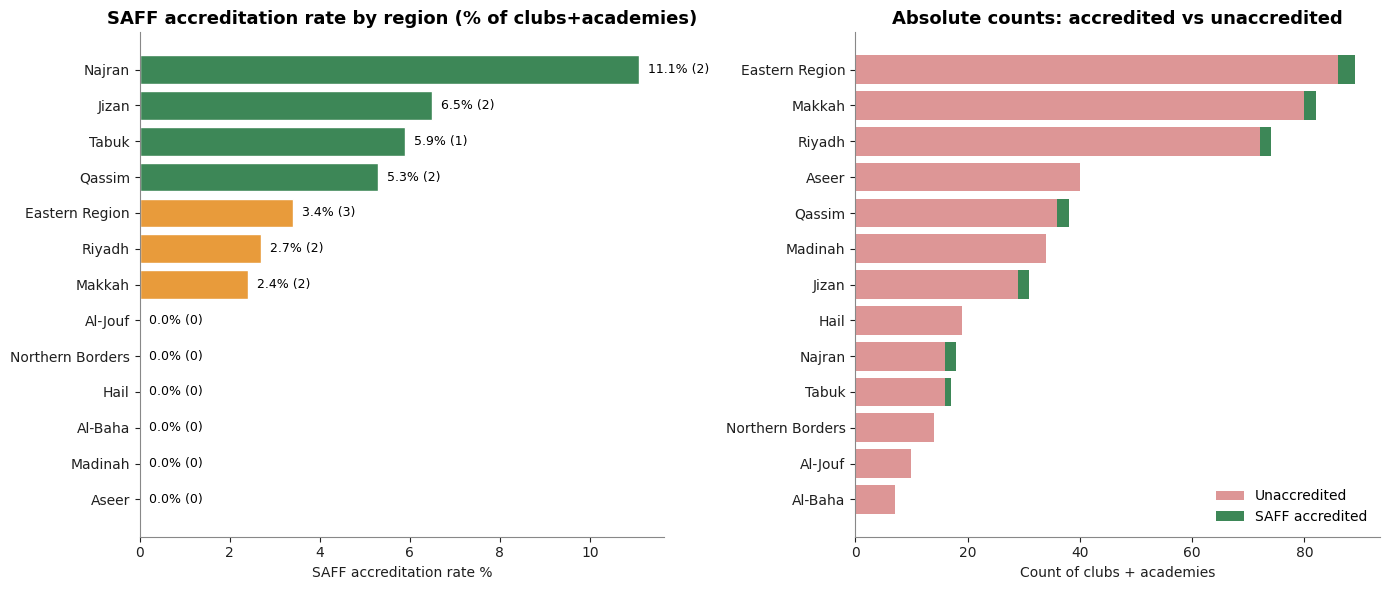


National SAFF accreditation rate: 3.0%
Regions with zero accredited: 6 of 13


In [28]:
# Accreditation rate by region
df_acc = df_master[['region_name_en','clubs','academies','saff_accredited','saff_accreditation_rate_pct']].copy()
df_acc['clubs_academies'] = df_acc['clubs'].astype(int) + df_acc['academies'].astype(int)
df_acc = df_acc.sort_values('saff_accreditation_rate_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) Accreditation rate %
ax = axes[0]
colors = [GREEN_DARK if r > 5 else (ORANGE_ACCENT if r > 0 else RED_ACCENT) for r in df_acc['saff_accreditation_rate_pct'].astype(float)]
ax.barh(df_acc['region_name_en'], df_acc['saff_accreditation_rate_pct'].astype(float),
        color=colors, edgecolor='white')
for i, (rate, count) in enumerate(zip(df_acc['saff_accreditation_rate_pct'].astype(float),
                                       df_acc['saff_accredited'].astype(int))):
    ax.text(rate + 0.2, i, f'{rate:.1f}% ({count})', va='center', fontsize=9)
ax.set_xlabel('SAFF accreditation rate %')
ax.set_title('SAFF accreditation rate by region (% of clubs+academies)')

# (b) Absolute count of accredited vs unaccredited
ax = axes[1]
df_acc_sorted = df_acc.sort_values('clubs_academies', ascending=True)
unacc = df_acc_sorted['clubs_academies'] - df_acc_sorted['saff_accredited'].astype(int)
ax.barh(df_acc_sorted['region_name_en'], unacc, color=RED_ACCENT, alpha=0.6, label='Unaccredited')
ax.barh(df_acc_sorted['region_name_en'], df_acc_sorted['saff_accredited'].astype(int),
        left=unacc, color=GREEN_DARK, label='SAFF accredited')
ax.set_xlabel('Count of clubs + academies')
ax.set_title('Absolute counts: accredited vs unaccredited')
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig(f'{OUTDIR}/06_saff_accreditation.png')
plt.show()

national_rate = df_master['saff_accredited'].sum() / (df_master['clubs'].sum() + df_master['academies'].sum()) * 100
print(f"\nNational SAFF accreditation rate: {national_rate:.1f}%")
print(f"Regions with zero accredited: {(df_master['saff_accredited']==0).sum()} of 13")


## 9. Women's facilities and PA (Q7/Q8)

Women's halls per 100k vs women's PA rate. The counter-intuitive finding: megaregions have the highest women's PA but lowest density per capita.

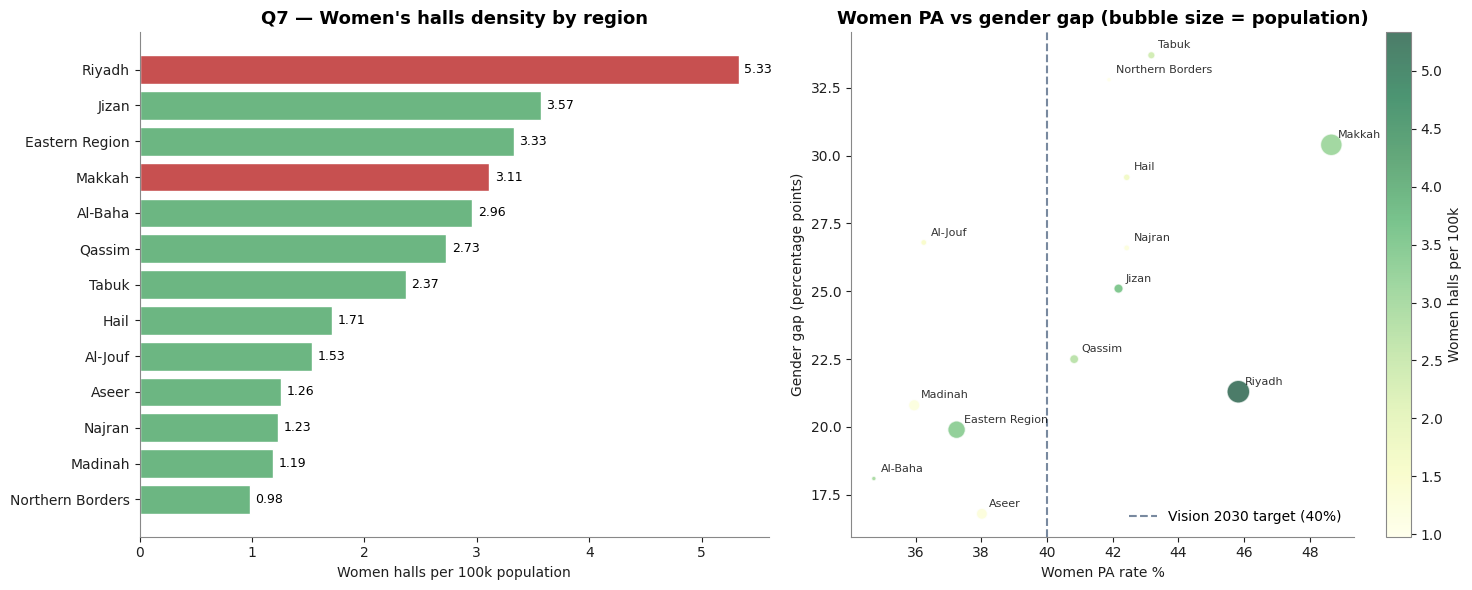

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Women's halls per 100k by region
ax = axes[0]
df_w = df_master.sort_values('women_halls_per_100k', ascending=True)
colors = [RED_ACCENT if r in ('Riyadh','Makkah') else GREEN_MID for r in df_w['region_name_en']]
ax.barh(df_w['region_name_en'], df_w['women_halls_per_100k'].astype(float),
        color=colors, edgecolor='white')
for i, v in enumerate(df_w['women_halls_per_100k'].astype(float)):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlabel('Women halls per 100k population')
ax.set_title('Q7 — Women\'s halls density by region')

# (b) Women's PA rate vs gender gap
ax = axes[1]
sizes = df_master['population'].astype(float) / 35000
sc = ax.scatter(df_master['pa_women_pct'].astype(float),
                df_master['gender_gap_pp'].astype(float),
                s=sizes, alpha=0.7, c=df_master['women_halls_per_100k'].astype(float),
                cmap='YlGn', edgecolors='white', linewidths=1)
ax.axvline(40, color=NAVY_ACCENT, ls='--', alpha=0.6, label='Vision 2030 target (40%)')
for _, row in df_master.iterrows():
    ax.annotate(row['region_name_en'],
                (float(row['pa_women_pct']), float(row['gender_gap_pp'])),
                fontsize=8, alpha=0.8, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Women PA rate %')
ax.set_ylabel('Gender gap (percentage points)')
ax.set_title('Women PA vs gender gap (bubble size = population)')
plt.colorbar(sc, ax=ax, label='Women halls per 100k')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f'{OUTDIR}/07_women_facilities.png')
plt.show()


## 10. Correlation matrix and Q9 hypothesis tests

Q9's headline finding: **building more pitches does NOT lift PA at the regional grain.** The Saudi correlation is negative (and inverted vs UK ONS findings).

,hypothesis,x_variable,y_variable,sample_subset,n,pearson_r,pearson_p,spearman_rho,weighted_r
0,H1,total_facilities_per_10k,pa_total_pct,all_regions,13,-0.242,0.425,-0.077,-0.540
1,H2,pitches_per_10k,pa_total_pct,all_regions,13,-0.265,0.381,-0.115,-0.558
2,H3,total_facilities_per_10k,pa_women_pct,all_regions,13,-0.438,0.134,-0.278,-0.701
3,H4,total_facilities_per_10k,pa_men_pct,all_regions,13,-0.177,0.564,0.011,-0.472
4,H5,academies_per_10k_youth,pa_total_pct,all_regions,13,0.186,0.543,0.033,NaN
5,H1_robust,total_facilities_per_10k,pa_total_pct,excl_riyadh_makkah,11,0.110,0.748,0.291,NaN
6,H3_robust,total_facilities_per_10k,pa_women_pct,excl_riyadh_makkah,11,0.059,0.864,0.187,NaN


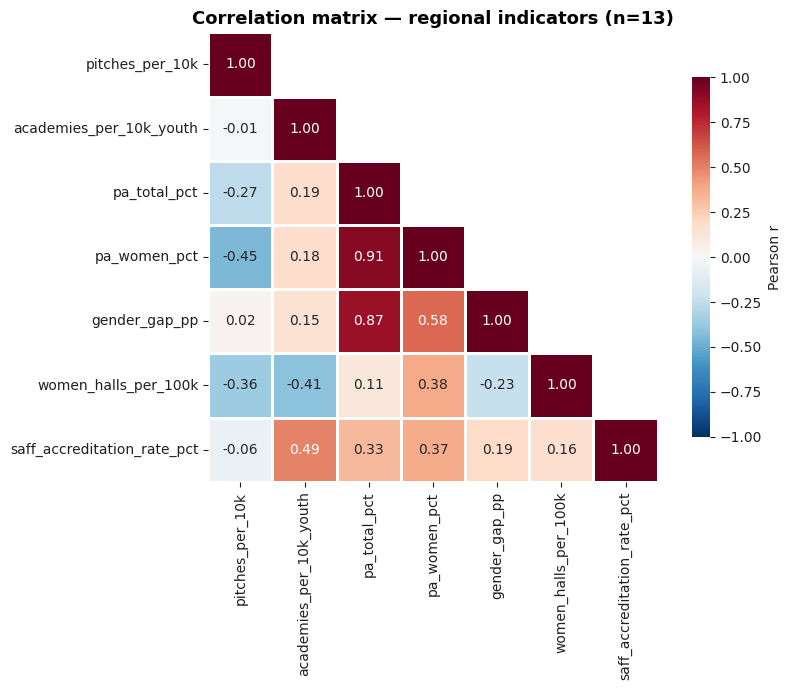

In [30]:
# Show all 7 hypothesis tests from q9_correlations
display(df_q9[['hypothesis','x_variable','y_variable','sample_subset','n','pearson_r','pearson_p','spearman_rho','weighted_r']])

# Build full correlation matrix on the 5 most-relevant numeric features
feat_cols = ['pitches_per_10k', 'academies_per_10k_youth', 'pa_total_pct', 'pa_women_pct',
             'gender_gap_pp', 'women_halls_per_100k', 'saff_accreditation_rate_pct']
corr_df = df_master[feat_cols].astype(float).corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, annot=True, fmt='.2f', mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, linecolor='white',
            cbar_kws={'label':'Pearson r','shrink':0.8}, ax=ax)
ax.set_title('Correlation matrix — regional indicators (n=13)')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/08_correlation_matrix.png')
plt.show()


### Q9 scatter — Saudi vs UK reference

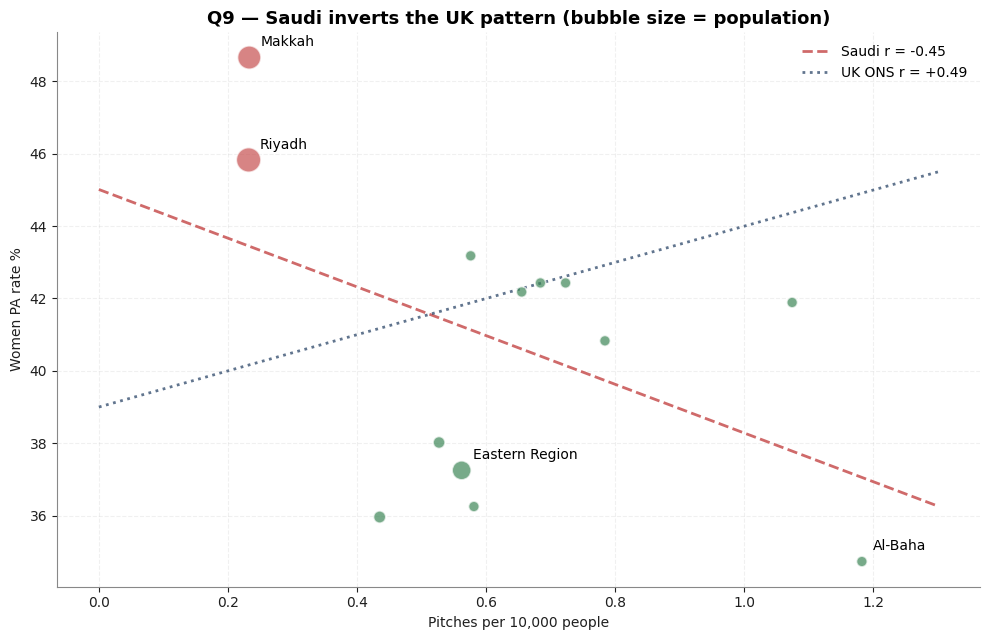


Saudi Pearson r: -0.452, p=0.121
Spearman rho:    -0.322
Pop-weighted r:  -0.715


In [31]:
# Q9 scatter: pitches per 10k vs women PA, with Saudi and UK trend lines
fig, ax = plt.subplots(figsize=(10, 6.5))

x = df_master['pitches_per_10k'].astype(float).values
y = df_master['pa_women_pct'].astype(float).values
pop = df_master['population'].astype(float).values
sizes = np.maximum(60, pop / 30000)

colors = [RED_ACCENT if r in ('Riyadh','Makkah') else GREEN_DARK for r in df_master['region_name_en']]
ax.scatter(x, y, s=sizes, c=colors, alpha=0.7, edgecolors='white', linewidths=1.2, zorder=3)

# Saudi trend (negative)
slope, intercept = np.polyfit(x, y, 1)
xx = np.linspace(0, 1.3, 50)
saudi_r = stats.pearsonr(x, y)[0]
ax.plot(xx, slope*xx + intercept, color=RED_ACCENT, ls='--', lw=2, alpha=0.85,
        label=f'Saudi r = {saudi_r:.2f}')

# UK ONS reference (positive, illustrative)
uk_y = 5.0 * (xx - 0.6) + 42
ax.plot(xx, uk_y, color=NAVY_ACCENT, ls=':', lw=2, alpha=0.7,
        label='UK ONS r = +0.49')

# Annotate megaregions and Al-Baha
for _, row in df_master.iterrows():
    if row['region_name_en'] in ('Riyadh','Makkah','Al-Baha','Eastern Region'):
        ax.annotate(row['region_name_en'],
                    (float(row['pitches_per_10k']), float(row['pa_women_pct'])),
                    fontsize=10, xytext=(8, 8), textcoords='offset points')

ax.set_xlabel('Pitches per 10,000 people')
ax.set_ylabel('Women PA rate %')
ax.set_title('Q9 — Saudi inverts the UK pattern (bubble size = population)')
ax.legend(loc='upper right', frameon=False)
ax.grid(True, alpha=0.18, ls='--')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/08b_q9_scatter.png')
plt.show()

print(f"\nSaudi Pearson r: {saudi_r:.3f}, p={stats.pearsonr(x,y)[1]:.3f}")
print(f"Spearman rho:    {stats.spearmanr(x,y)[0]:.3f}")
# Population-weighted correlation
w = pop / pop.sum()
mx, my = np.average(x, weights=w), np.average(y, weights=w)
cov = np.sum(w * (x-mx) * (y-my))
sx = np.sqrt(np.sum(w * (x-mx)**2))
sy = np.sqrt(np.sum(w * (y-my)**2))
print(f"Pop-weighted r:  {cov/(sx*sy):.3f}")


## 11. Q10 — Investment tier priorities

Tier 1 = highest leverage for Vision 2030 women's PA lift. Combines low women's PA with large inactive populations.

,region_name_en,population,pa_women_pct,gender_gap_pp,estimated_inactive_women_18plus,women_halls_per_100k,pitches_per_10k,tier_label
2,Eastern Region,5623050,37.25,19.9,962847.0,3.33,0.562,Tier 1: primary
5,Madinah,2345637,35.96,20.8,409906.0,1.19,0.435,Tier 1: primary
6,Aseer,2220896,38.02,16.8,375622.0,1.26,0.527,Tier 1: primary
0,Riyadh,9426231,45.83,21.3,1393377.0,5.33,0.232,Tier 2: scale
1,Makkah,8524663,48.66,30.4,1194276.0,3.11,0.233,Tier 2: scale
3,Jizan,1541458,42.18,25.1,243210.0,3.57,0.655,Tier 2: candidate
4,Qassim,1465956,40.83,22.5,236698.0,2.73,0.784,Tier 2: candidate
7,Tabuk,972093,43.18,33.7,150723.0,2.37,0.576,Tier 3: defer
8,Hail,818901,42.43,29.2,128647.0,1.71,0.684,Tier 3: defer
10,Al-Jouf,653691,36.25,26.8,113717.0,1.53,0.581,Tier 3: defer


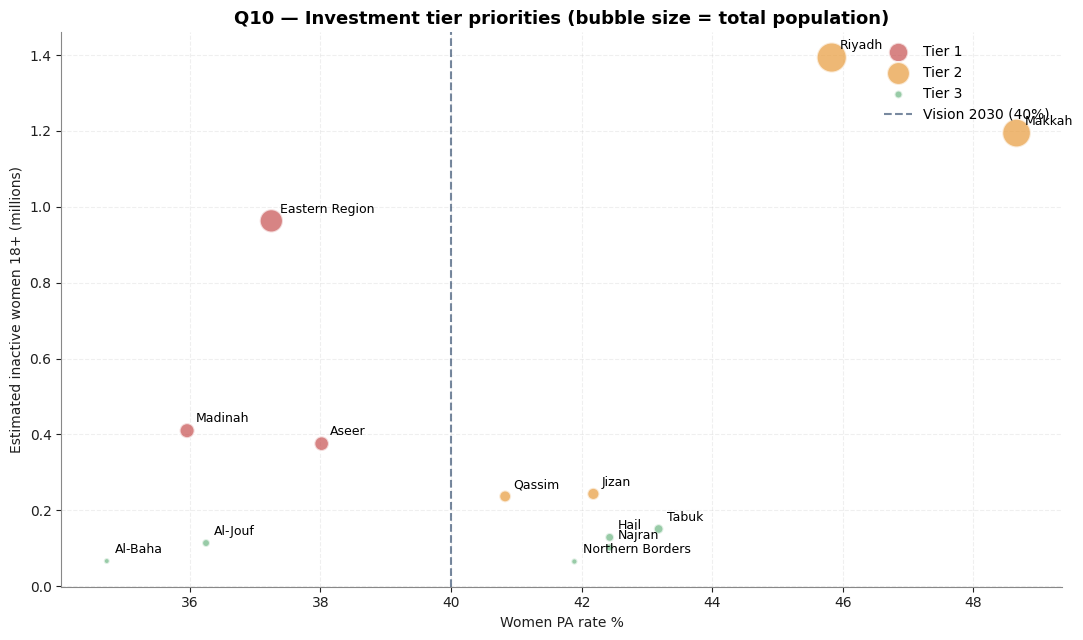

In [32]:
# Priorities table
df_pri = df_priorities.copy()
df_pri['estimated_inactive_women_18plus'] = df_pri['estimated_inactive_women_18plus'].astype(float)
df_pri = df_pri.sort_values(['investment_tier','estimated_inactive_women_18plus'], ascending=[True, False])
display(df_pri[['region_name_en','population','pa_women_pct','gender_gap_pp',
                'estimated_inactive_women_18plus','women_halls_per_100k',
                'pitches_per_10k','tier_label']])

# Tier visualization — bubble plot
fig, ax = plt.subplots(figsize=(11, 6.5))
tier_colors = {1: RED_ACCENT, 2: ORANGE_ACCENT, 3: GREEN_MID}
for tier in sorted(df_pri['investment_tier'].unique()):
    sub = df_pri[df_pri['investment_tier']==tier]
    ax.scatter(sub['pa_women_pct'].astype(float),
               sub['estimated_inactive_women_18plus'].astype(float)/1e6,
               s=sub['population'].astype(float)/20000,
               c=tier_colors.get(tier, GRAY_MUTED), alpha=0.7,
               edgecolors='white', linewidths=1.5, label=f'Tier {tier}', zorder=3)

for _, row in df_pri.iterrows():
    ax.annotate(row['region_name_en'],
                (float(row['pa_women_pct']),
                 float(row['estimated_inactive_women_18plus'])/1e6),
                fontsize=9, xytext=(6, 6), textcoords='offset points')

ax.axvline(40, color=NAVY_ACCENT, ls='--', alpha=0.6, label='Vision 2030 (40%)')
ax.set_xlabel('Women PA rate %')
ax.set_ylabel('Estimated inactive women 18+ (millions)')
ax.set_title('Q10 — Investment tier priorities (bubble size = total population)')
ax.legend(loc='upper right', frameon=False)
ax.grid(True, alpha=0.2, ls='--')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/09_q10_priorities.png')
plt.show()


## 12. Country benchmark — Saudi vs Germany / Japan / Türkiye

Germany = gold standard. Japan = vision pathway. Türkiye = peer market.

,country,population_M,registered_per_1000,all_clubs,top_tier,pa_pct
0,Saudi Arabia,35.3,0.85,473,18,59.0
1,Türkiye,85.5,5.50,4500,20,60.1
2,Japan,124.0,6.73,1200,20,NaN
3,Germany,83.4,79.13,24300,18,NaN


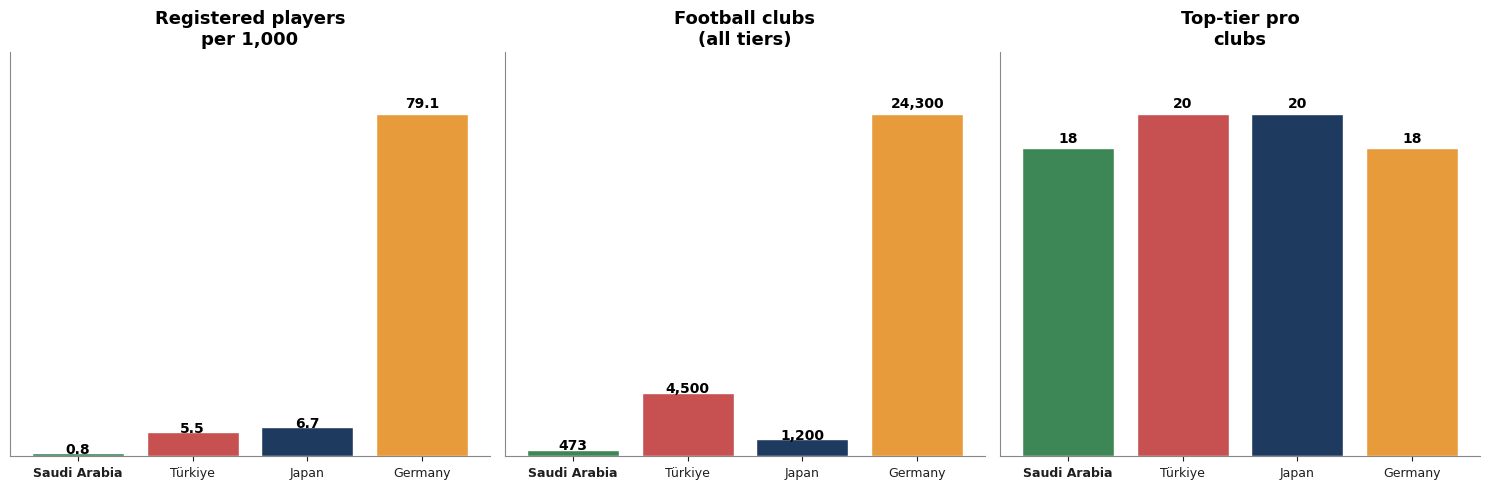

In [33]:
# Hard-coded benchmark data (sources: DFB 2020, JFA 2024, TFF, this study)
benchmark = pd.DataFrame([
    {'country':'Saudi Arabia','population_M':35.3,'registered_per_1000':0.85,'all_clubs':473,'top_tier':18,'pa_pct':59.0},
    {'country':'Türkiye',     'population_M':85.5,'registered_per_1000':5.50,'all_clubs':4500,'top_tier':20,'pa_pct':60.1},
    {'country':'Japan',       'population_M':124.0,'registered_per_1000':6.73,'all_clubs':1200,'top_tier':20,'pa_pct':None},
    {'country':'Germany',     'population_M':83.4,'registered_per_1000':79.13,'all_clubs':24300,'top_tier':18,'pa_pct':None},
])
display(benchmark)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
country_colors = [GREEN_DARK, RED_ACCENT, NAVY_ACCENT, ORANGE_ACCENT]

for ax, (col, label, fmt) in zip(axes, [
    ('registered_per_1000', 'Registered players\nper 1,000', '{:.1f}'),
    ('all_clubs',           'Football clubs\n(all tiers)',   '{:,.0f}'),
    ('top_tier',            'Top-tier pro\nclubs',           '{:.0f}'),
]):
    bars = ax.bar(benchmark['country'], benchmark[col], color=country_colors, edgecolor='white')
    for bar, v in zip(bars, benchmark[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                fmt.format(v), ha='center', fontsize=10, fontweight='bold')
    ax.set_title(label)
    ax.set_yticks([])
    ax.set_ylim(0, benchmark[col].max() * 1.18)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=9)
    # Bold Saudi tick
    for tick, country in zip(ax.get_xticklabels(), benchmark['country']):
        if country == 'Saudi Arabia': tick.set_fontweight('bold')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/10_benchmark.png')
plt.show()


## 13. K-means clustering — natural region groups

Group regions by 6 features (population, density, women PA, gender gap, women's halls density, accreditation rate) into 3 archetypes.

,region_name_en,cluster_label,population,pitches_per_10k,pa_women_pct,gender_gap_pp,women_halls_per_100k,saff_accreditation_rate_pct
3,Jizan,Low-density rural,1541458,0.655,42.18,25.1,3.57,6.5
4,Qassim,Low-density rural,1465956,0.784,40.83,22.5,2.73,5.3
7,Tabuk,Low-density rural,972093,0.576,43.18,33.7,2.37,5.9
8,Hail,Low-density rural,818901,0.684,42.43,29.2,1.71,0.0
11,Najran,Low-density rural,649827,0.723,42.43,26.6,1.23,11.1
12,Northern Borders,Low-density rural,409861,1.074,41.89,32.8,0.98,0.0
0,Riyadh,Megaregion,9426231,0.232,45.83,21.3,5.33,2.7
1,Makkah,Megaregion,8524663,0.233,48.66,30.4,3.11,2.4
2,Eastern Region,Mid-tier,5623050,0.562,37.25,19.9,3.33,3.4
5,Madinah,Mid-tier,2345637,0.435,35.96,20.8,1.19,0.0


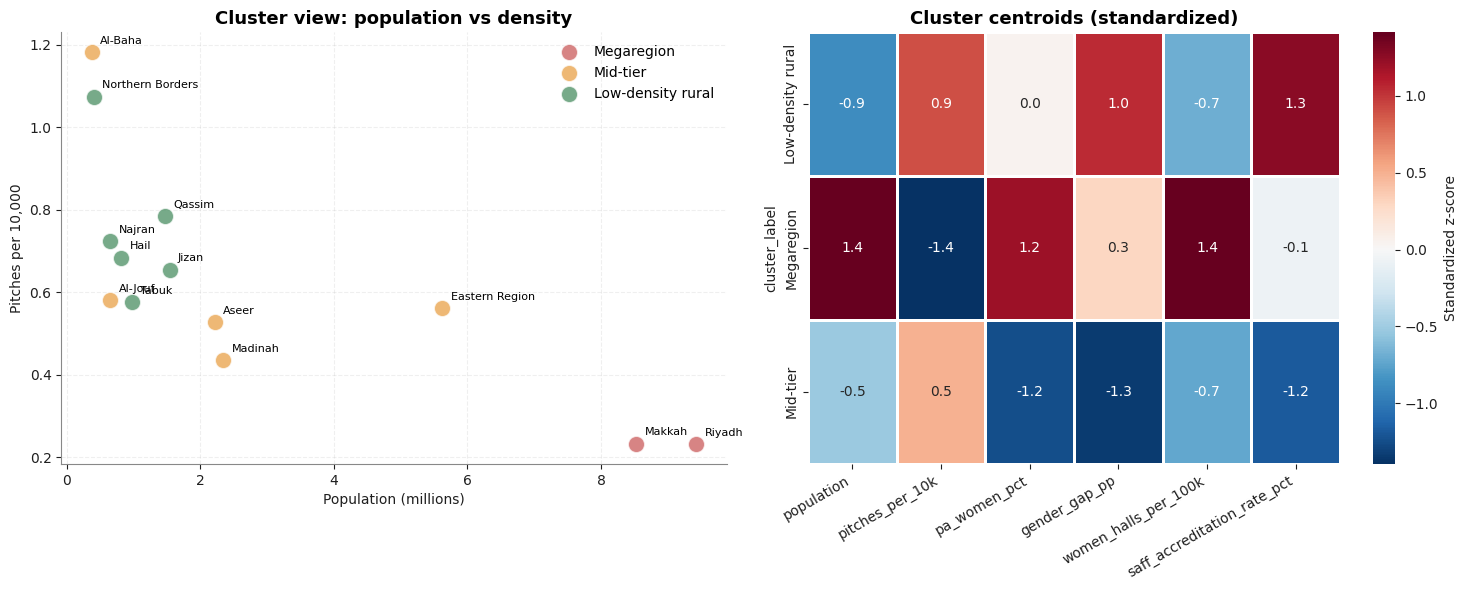

In [34]:
features = ['population','pitches_per_10k','pa_women_pct','gender_gap_pp',
            'women_halls_per_100k','saff_accreditation_rate_pct']
X = df_master[features].astype(float).fillna(0).values
Xs = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xs)
df_master_c = df_master.copy()
df_master_c['cluster'] = kmeans.labels_

# Name clusters by their dominant trait (largest population = "megaregion", etc.)
cluster_means = df_master_c.groupby('cluster')[features].mean().astype(float)
cluster_pop = cluster_means['population']
order = cluster_pop.sort_values(ascending=False).index.tolist()
labels = {order[0]:'Megaregion', order[1]:'Mid-tier', order[2]:'Low-density rural'}
df_master_c['cluster_label'] = df_master_c['cluster'].map(labels)

display(df_master_c[['region_name_en','cluster_label','population',
                     'pitches_per_10k','pa_women_pct','gender_gap_pp',
                     'women_halls_per_100k','saff_accreditation_rate_pct']]
        .sort_values(['cluster_label','population'], ascending=[True, False]))

# Visualize: PCA-style 2D projection using two strongest features
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cluster_palette = {'Megaregion':RED_ACCENT, 'Mid-tier':ORANGE_ACCENT, 'Low-density rural':GREEN_DARK}

# (a) population vs density
ax = axes[0]
for cl, color in cluster_palette.items():
    sub = df_master_c[df_master_c['cluster_label']==cl]
    ax.scatter(sub['population'].astype(float)/1e6,
               sub['pitches_per_10k'].astype(float),
               c=color, s=140, alpha=0.7, edgecolors='white', label=cl, zorder=3)
for _, row in df_master_c.iterrows():
    ax.annotate(row['region_name_en'],
                (float(row['population'])/1e6, float(row['pitches_per_10k'])),
                fontsize=8, xytext=(6,6), textcoords='offset points')
ax.set_xlabel('Population (millions)')
ax.set_ylabel('Pitches per 10,000')
ax.set_title('Cluster view: population vs density')
ax.legend(frameon=False)
ax.grid(alpha=0.2, ls='--')

# (b) cluster centroid radar (heatmap of standardized means)
ax = axes[1]
centroid_means = df_master_c.groupby('cluster_label')[features].mean().astype(float)
centroid_z = (centroid_means - cluster_means.values.mean(0)) / cluster_means.values.std(0)
sns.heatmap(centroid_z[features], annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label':'Standardized z-score'}, linewidths=1, linecolor='white', ax=ax)
ax.set_title('Cluster centroids (standardized)')
ax.set_xlabel('')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/11_clusters.png')
plt.show()


## 14. Pitch supply gap to UEFA target

If every region needed 1.0 pitch per 10k (UEFA "well-served" benchmark), how many additional pitches are required and where?

,region_name_en,population,actual_pitches,target_pitches,gap,gap_pct
9,Al-Baha,"372,116",44,37,-7,-18%
12,Northern Borders,"409,861",44,41,-3,-7%
11,Najran,"649,827",47,65,18,28%
8,Hail,"818,901",56,82,26,32%
10,Al-Jouf,"653,691",38,65,27,42%
4,Qassim,"1,465,956",115,147,32,22%
7,Tabuk,"972,093",56,97,41,42%
3,Jizan,"1,541,458",101,154,53,34%
6,Aseer,"2,220,896",117,222,105,47%
5,Madinah,"2,345,637",102,235,133,57%


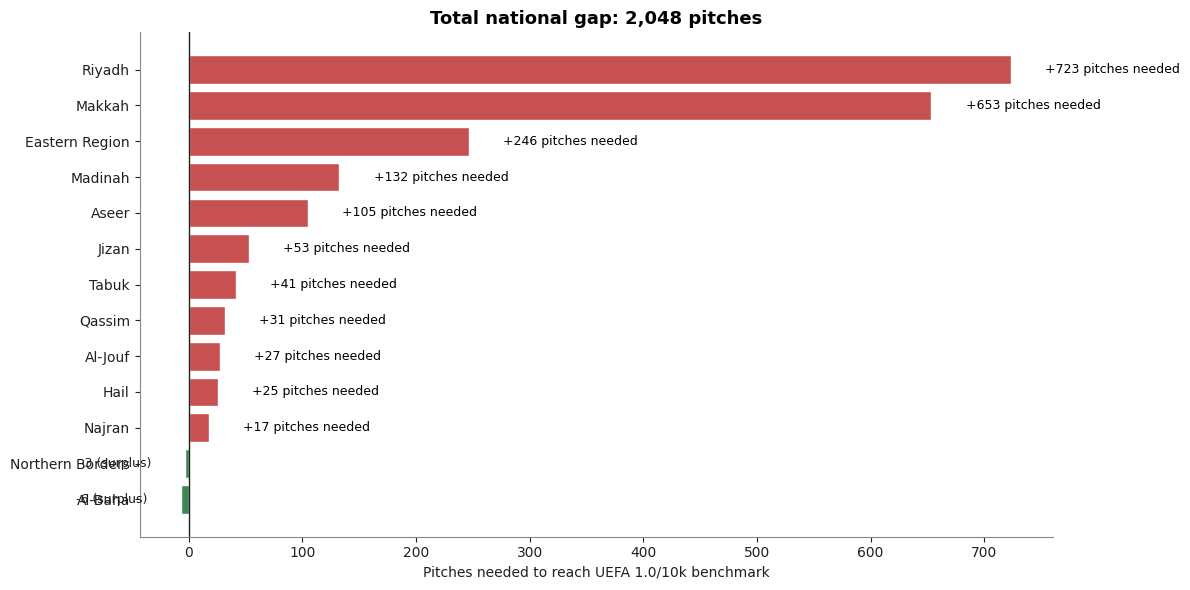


Total pitches today:    1,454
Target (UEFA 1.0/10k):  3,502
National gap:           2,048 additional pitches


In [35]:
df_gap = df_master.copy()
df_gap['target_pitches'] = (df_gap['population'].astype(float) / 10000.0)
df_gap['actual_pitches'] = df_gap['pitches'].astype(float)
df_gap['gap'] = df_gap['target_pitches'] - df_gap['actual_pitches']
df_gap['gap_pct'] = df_gap['gap'] / df_gap['target_pitches'] * 100
df_gap = df_gap.sort_values('gap', ascending=True)

display(df_gap[['region_name_en','population','actual_pitches','target_pitches','gap','gap_pct']]
        .style.format({'population':'{:,.0f}','actual_pitches':'{:.0f}',
                       'target_pitches':'{:.0f}','gap':'{:,.0f}','gap_pct':'{:.0f}%'}))

# Visualize gap
fig, ax = plt.subplots(figsize=(12, 6))
df_gap_v = df_gap.sort_values('gap')
colors = [RED_ACCENT if g > 0 else GREEN_DARK for g in df_gap_v['gap']]
bars = ax.barh(df_gap_v['region_name_en'], df_gap_v['gap'], color=colors, edgecolor='white')
for bar, g, pct in zip(bars, df_gap_v['gap'], df_gap_v['gap_pct']):
    if g > 0:
        ax.text(g + 30, bar.get_y()+bar.get_height()/2, f'+{int(g):,} pitches needed',
                va='center', fontsize=9)
    else:
        ax.text(g - 30, bar.get_y()+bar.get_height()/2, f'{int(g):,} (surplus)',
                va='center', ha='right', fontsize=9, color='white' if abs(g)>50 else TEXT_DARK)
ax.axvline(0, color=TEXT_DARK, lw=1.0)
ax.set_xlabel('Pitches needed to reach UEFA 1.0/10k benchmark')
ax.set_title(f'Total national gap: {int(df_gap["gap"].sum()):,} pitches')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/12_uefa_gap.png')
plt.show()

print(f"\nTotal pitches today:    {int(df_gap['actual_pitches'].sum()):,}")
print(f"Target (UEFA 1.0/10k):  {int(df_gap['target_pitches'].sum()):,}")
print(f"National gap:           {int(df_gap['gap'].sum()):,} additional pitches")


## 15. Google rating distribution by facility type

Reliable subset: only facilities with 50+ reviews. Gives a rough quality signal.

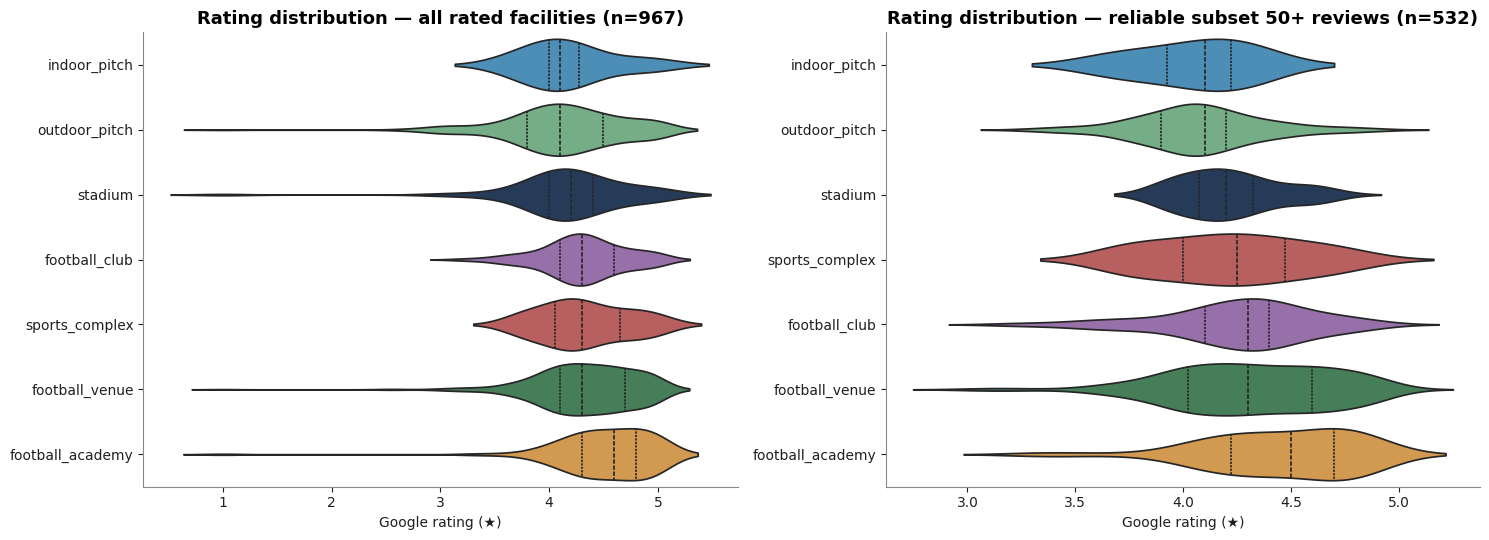


Mean rating (all):      4.28
Mean rating (reliable): 4.26
Reliable subset size:   532 (55.0%)


In [36]:
df_rating = df_facilities.dropna(subset=['google_rating']).copy()
df_rating['google_rating'] = df_rating['google_rating'].astype(float)
df_rating['google_reviews_count'] = df_rating['google_reviews_count'].astype(float).fillna(0)
reliable = df_rating[df_rating['google_reviews_count'] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) violin per type, all
ax = axes[0]
order = df_rating.groupby('facility_type')['google_rating'].median().sort_values().index.tolist()
sns.violinplot(data=df_rating, x='google_rating', y='facility_type', order=order,
               palette=[colors_map.get(t, GREEN_MID) for t in order], inner='quartile', ax=ax)
ax.set_title(f'Rating distribution — all rated facilities (n={len(df_rating):,})')
ax.set_xlabel('Google rating (★)')
ax.set_ylabel('')

# (b) violin per type, reliable subset only
ax = axes[1]
order_r = reliable.groupby('facility_type')['google_rating'].median().sort_values().index.tolist()
sns.violinplot(data=reliable, x='google_rating', y='facility_type', order=order_r,
               palette=[colors_map.get(t, GREEN_MID) for t in order_r], inner='quartile', ax=ax)
ax.set_title(f'Rating distribution — reliable subset 50+ reviews (n={len(reliable):,})')
ax.set_xlabel('Google rating (★)')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/13_ratings.png')
plt.show()

print(f"\nMean rating (all):      {df_rating['google_rating'].mean():.2f}")
print(f"Mean rating (reliable): {reliable['google_rating'].mean():.2f}")
print(f"Reliable subset size:   {len(reliable):,} ({len(reliable)/len(df_rating)*100:.1f}%)")


## 16. Academy density vs registered-player proxy

We don't have per-region registered-player counts (SAFF doesn't publish), so we use **academy count** as a proxy for the youth pipeline.

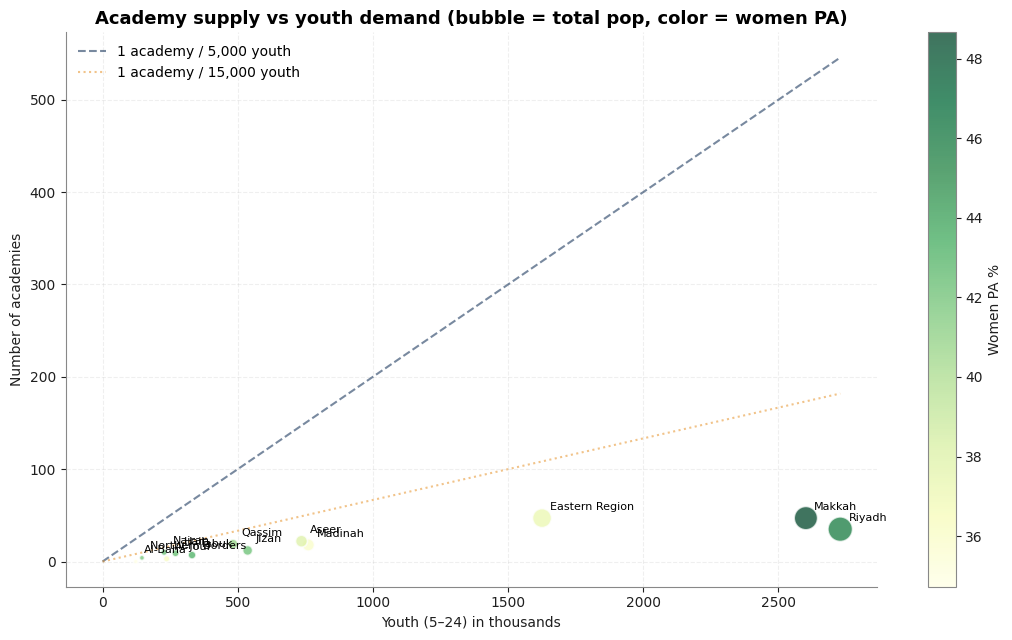

Worst youth-per-academy ratios (potentially under-served):
region_name_en  youth_5_24  academies        ratio
       Al-Jouf    236948.0          3 78982.666667
        Riyadh   2728550.0         35 77958.571429
        Makkah   2601509.0         47 55351.255319
         Tabuk    331002.0          7 47286.000000
         Jizan    536713.0         12 44726.083333


In [37]:
# Academy density vs youth population
fig, ax = plt.subplots(figsize=(11, 6.5))
df_yp = df_master.copy()
df_yp['youth_5_24'] = df_yp['youth_5_24'].astype(float)
df_yp['academies'] = df_yp['academies'].astype(int)
df_yp['ratio'] = df_yp['youth_5_24'] / df_yp['academies'].replace(0, np.nan)

sc = ax.scatter(df_yp['youth_5_24']/1000, df_yp['academies'],
                s=df_yp['population'].astype(float)/30000,
                c=df_yp['pa_women_pct'].astype(float), cmap='YlGn',
                alpha=0.75, edgecolors='white', linewidths=1.2, zorder=3)
for _, row in df_yp.iterrows():
    if row['academies'] >= 0:
        ax.annotate(row['region_name_en'],
                    (float(row['youth_5_24'])/1000, int(row['academies'])),
                    fontsize=8, xytext=(6,6), textcoords='offset points')
# Draw a "1 academy per 5,000 youth" reference
xx = np.linspace(0, df_yp['youth_5_24'].max()/1000, 100)
ax.plot(xx, xx*1000/5000, color=NAVY_ACCENT, ls='--', alpha=0.6, label='1 academy / 5,000 youth')
ax.plot(xx, xx*1000/15000, color=ORANGE_ACCENT, ls=':', alpha=0.6, label='1 academy / 15,000 youth')

ax.set_xlabel('Youth (5–24) in thousands')
ax.set_ylabel('Number of academies')
ax.set_title('Academy supply vs youth demand (bubble = total pop, color = women PA)')
ax.legend(frameon=False)
plt.colorbar(sc, ax=ax, label='Women PA %')
ax.grid(alpha=0.2, ls='--')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/14_academy_vs_youth.png')
plt.show()

# Worst youth-per-academy ratios
print("Worst youth-per-academy ratios (potentially under-served):")
print(df_yp[df_yp['academies']>0].nlargest(5, 'ratio')[['region_name_en','youth_5_24','academies','ratio']]
      .to_string(index=False))


## 17. Vision 2030 target tracking

Vision 2030 quality-of-life targets include 40% adult PA. National average: 59%. By region…

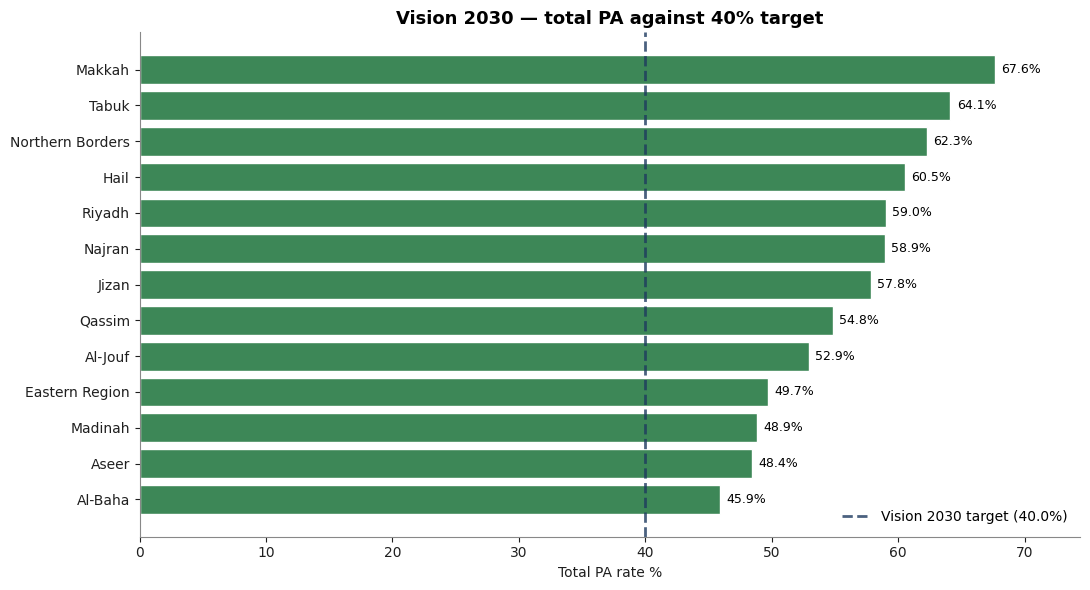


Regions BELOW Vision 2030 target: 0 of 13
  All 13 regions above target ✓


In [38]:
TARGET_PA = 40.0

fig, ax = plt.subplots(figsize=(11, 6))
df_t = df_master.sort_values('pa_total_pct', ascending=True)
colors = [GREEN_DARK if p >= TARGET_PA else RED_ACCENT for p in df_t['pa_total_pct'].astype(float)]
ax.barh(df_t['region_name_en'], df_t['pa_total_pct'].astype(float),
        color=colors, edgecolor='white')
ax.axvline(TARGET_PA, color=NAVY_ACCENT, ls='--', lw=2, alpha=0.8, label=f'Vision 2030 target ({TARGET_PA}%)')
for i, v in enumerate(df_t['pa_total_pct'].astype(float)):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Total PA rate %')
ax.set_title('Vision 2030 — total PA against 40% target')
ax.set_xlim(0, max(df_t['pa_total_pct'].astype(float).max() * 1.10, 65))
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/15_vision_2030.png')
plt.show()

below = df_master[df_master['pa_total_pct'].astype(float) < TARGET_PA]
print(f"\nRegions BELOW Vision 2030 target: {len(below)} of 13")
if len(below) > 0:
    for _, row in below.iterrows():
        print(f"  {row['region_name_en']}: {row['pa_total_pct']}%")
else:
    print("  All 13 regions above target ✓")


## 18. Export — save everything

All charts already saved as PNG. Now also dump the DataFrames as CSV so you can open them in Excel.

In [39]:
# CSV exports
exports = {
    'regional_master': df_master,
    'facilities': df_facilities,
    'priorities_q10': df_priorities,
    'data_quality': df_quality,
    'pitch_deserts_q3': df_q3,
    'correlations_q9': df_q9,
    'population_estimates_q2': df_q2_pop,
    'sample_coding_q2': df_q2_sample,
    'demographics': df_demographics,
    'pa_2025': df_pa,
    'women_facilities': df_women,
    'saff_accredited': df_saff,
}
for name, df in exports.items():
    df.to_csv(f'{OUTDIR}/{name}.csv', index=False)

print(f"Exported {len(exports)} CSVs to {OUTDIR}/")
print()
print('Files in output:')
for f in sorted(os.listdir(OUTDIR)):
    size_kb = os.path.getsize(f'{OUTDIR}/{f}') / 1024
    print(f'  {f:40s} {size_kb:>8.1f} KB')


Exported 12 CSVs to /content/outputs/

Files in output:
  01_data_quality.png                          65.5 KB
  02_facility_types.png                        95.4 KB
  03_regional_density.png                     126.9 KB
  04_interactive_map.html                    1188.9 KB
  04b_density_heatmap.html                     28.9 KB
  05_pitch_deserts.png                         61.6 KB
  05b_distance_distribution.png                36.9 KB
  06_saff_accreditation.png                   115.5 KB
  07_women_facilities.png                     139.5 KB
  08_correlation_matrix.png                   118.8 KB
  08b_q9_scatter.png                          104.8 KB
  09_q10_priorities.png                        97.1 KB
  10_benchmark.png                             46.0 KB
  11_clusters.png                             164.1 KB
  12_uefa_gap.png                              97.0 KB
  13_ratings.png                              190.3 KB
  14_academy_vs_youth.png                     123.6 KB
  15_visi

### Download everything as a zip

Run this last cell to bundle all outputs and trigger a Colab download.

In [40]:
import shutil
shutil.make_archive('/content/saudi_football_outputs', 'zip', OUTDIR)
print('Created /content/saudi_football_outputs.zip')

# Trigger browser download in Colab
try:
    from google.colab import files
    files.download('/content/saudi_football_outputs.zip')
except ImportError:
    print('Not in Colab — find the zip at /content/saudi_football_outputs.zip')


Created /content/saudi_football_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Notes

- All correlations use n=13 regions, which is small. Treat r values as directional, not precise.
- Q3 pitch deserts use Euclidean distance; real walking distance is 1.2-1.4× longer.
- Women's PA per region is a hybrid estimate (2025 total × 2021 within-region gender ratio).
- Türkiye benchmark uses top-line stats only (TFF doesn't publish detailed registered-player counts).
- SAFF accredited list dates from October 2023; refresh when SAFF publishes a new list.

**Refresh:** re-run the data-load cell to pull current Supabase data. Charts auto-rebuild.

**Issues:** the publishable key is read-only. If you need to add or modify data, use the Supabase dashboard (not this notebook).
